In [4]:
import pandas as pd

test = pd.read_csv("a5dec952-c449-4fc5-80f0-85a2246884bf.rna_seq.augmented_star_gene_counts.tsv",sep="\t")
print(test)

                  gene_id   gene_name       gene_type  unstranded  \
0              N_unmapped         NaN             NaN     1195534   
1          N_multimapping         NaN             NaN    11416899   
2             N_noFeature         NaN             NaN    38969233   
3             N_ambiguous         NaN             NaN     6445444   
4      ENSG00000000003.15      TSPAN6  protein_coding        2187   
...                   ...         ...             ...         ...   
60659   ENSG00000288669.1  AC008763.4  protein_coding           0   
60660   ENSG00000288670.1  AL592295.6          lncRNA         279   
60661   ENSG00000288671.1  AC006486.3  protein_coding           0   
60662   ENSG00000288674.1  AL391628.1  protein_coding          17   
60663   ENSG00000288675.1  AP006621.6  protein_coding          15   

       stranded_first  stranded_second  tpm_unstranded  fpkm_unstranded  \
0             1195534          1195534             NaN              NaN   
1            11416899

In [1]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

print(dir(diff))

['PCA', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'differential_expression', 'multipletests', 'np', 'pca_plot', 'pd', 'plt', 'ttest_ind', 'volcano_plot']


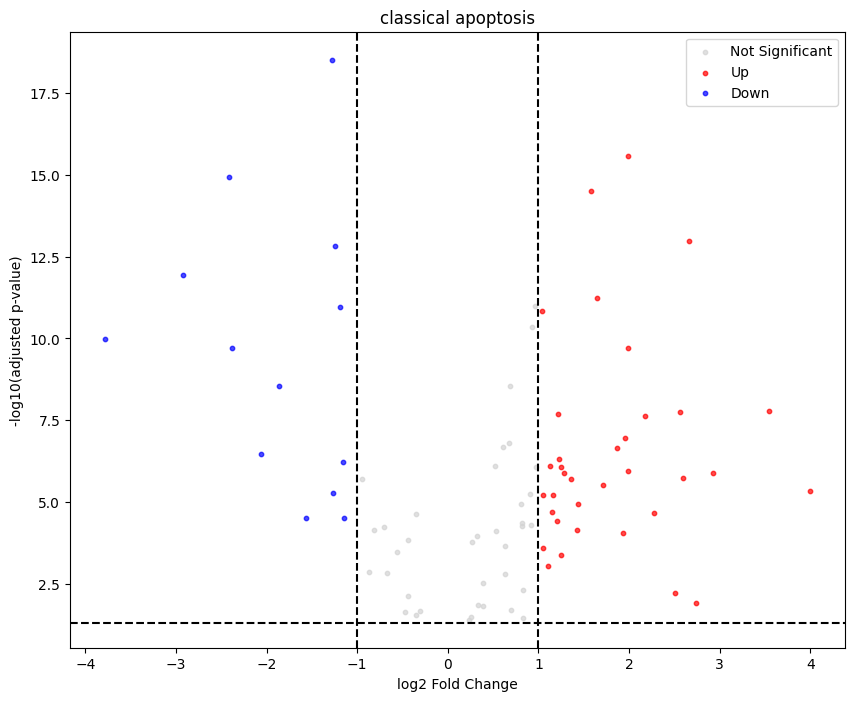

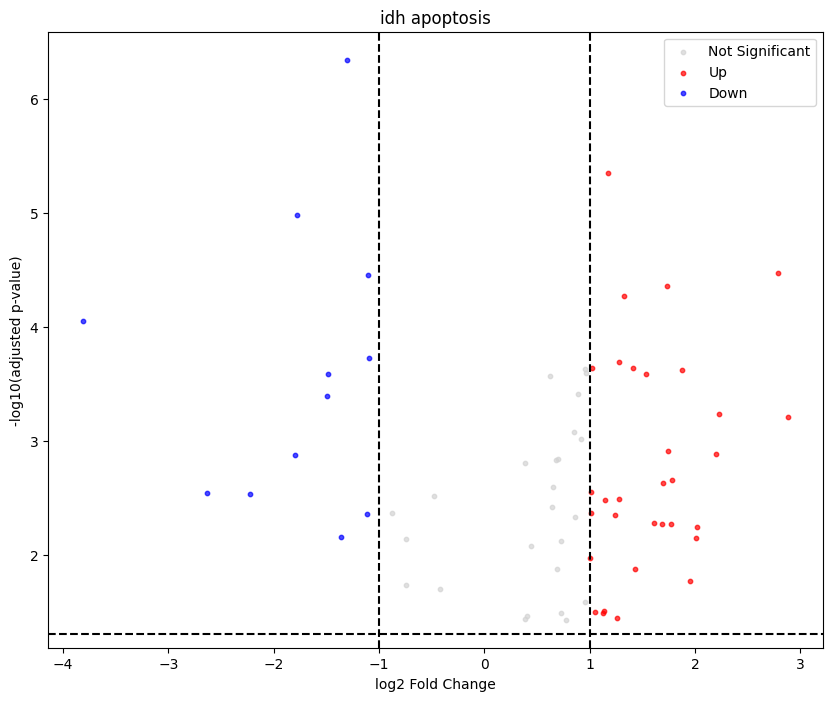

In [2]:
import pandas as pd
clas = pd.read_csv("../data/processed/pathway_diff/classical/classical_Apoptosis_diff.csv",index_col=0)[["log2FC_rna","-log(adjustedp)_rna","category_rna"]]
idh = pd.read_csv("../data/processed/pathway_diff/idh/idh_Apoptosis_diff.csv",index_col=0)[["log2FC_rna","-log(adjustedp)_rna","category_rna"]]

diff.volcano_plot(clas,'classical apoptosis')
diff.volcano_plot(idh,'idh apoptosis')

In [1]:
import pandas as pd
from pathlib import Path

subtypes = [
    "proneural",
    "classical",
    "mesenchymal",
    "idh"
]

input_dir = Path("../data/interim")
output_dir = Path("../data/processed/diff")

for subtype in subtypes:

    rna = pd.read_csv(
        input_dir / f"{subtype}_rna_diff.csv",
        index_col=0
    )

    prot = pd.read_csv(
        input_dir / f"{subtype}_pro_diff.csv",
        index_col=0
    )

    # Keep only genes present in both datasets
    common = rna.index.intersection(prot.index)

    combined = (
        rna.loc[common]
        .join(
            prot.loc[common],
            lsuffix="_rna",
            rsuffix="_prot"
        )
        .sort_index()
    )

    combined.to_csv(
        output_dir / f"{subtype}_combined.csv"
    )

    print(f"{subtype}: {combined.shape[0]} genes")

proneural: 10074 genes
classical: 10074 genes
mesenchymal: 10074 genes
idh: 10074 genes


c:\Users\haina\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


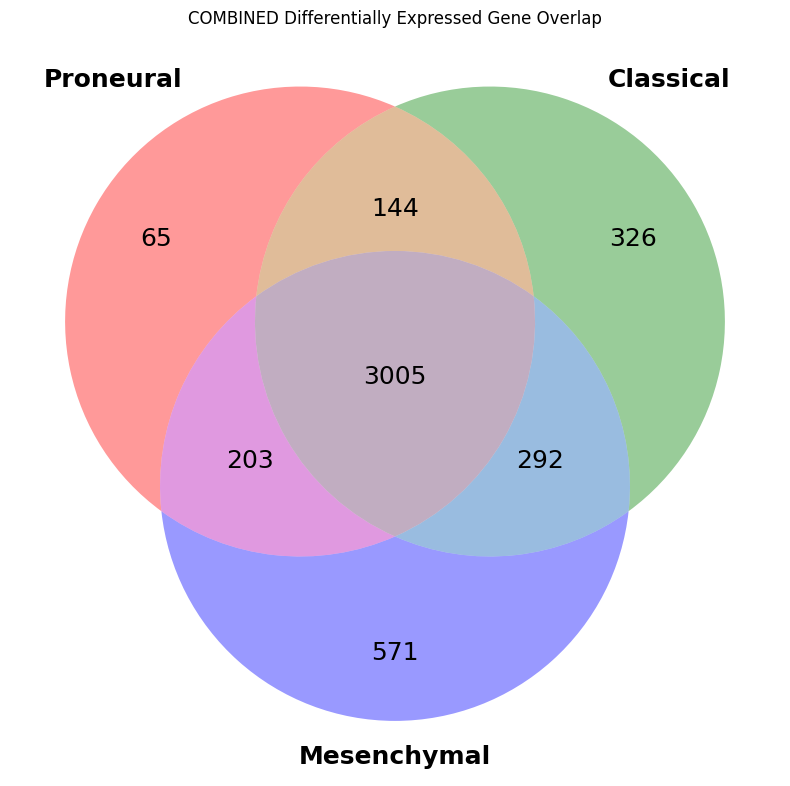

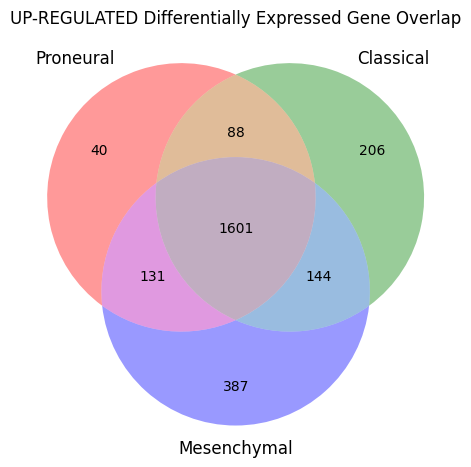

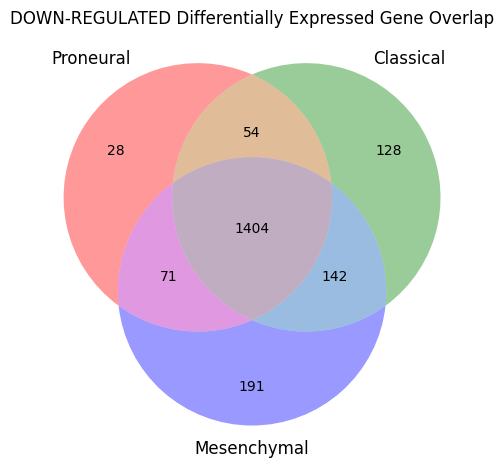

In [6]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3_unweighted
import pandas as pd

# -----------------------------
# Settings
# -----------------------------
PVAL_COLUMN = "pvalue"
LOGFC_COLUMN = "log2FC"
GENE_COLUMN = "gene_name"

PVAL_THRESHOLD = 0.05
LOGFC_THRESHOLD = 1

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv"
}

# -----------------------------
# Load DEG sets
# -----------------------------
gene_sets = {}
gene_sets_up = {}
gene_sets_down = {}

for subtype, file in files.items():

    df = pd.read_csv(file)

    sig = df[
        (df[PVAL_COLUMN] < PVAL_THRESHOLD) &
        (abs(df[LOGFC_COLUMN]) > LOGFC_THRESHOLD)
    ]

    sig_up  = df[
    (df[PVAL_COLUMN] < PVAL_THRESHOLD) &
    (df[LOGFC_COLUMN] > LOGFC_THRESHOLD)
    ]
    
    sig_down = df[
    (df[PVAL_COLUMN] < PVAL_THRESHOLD) &
    (df[LOGFC_COLUMN] < -LOGFC_THRESHOLD)
    ]
    
    gene_sets[subtype] = set(
        sig[GENE_COLUMN]
        .dropna()
        .astype(str)
    )

    gene_sets_up[subtype] = set(
        sig_up[GENE_COLUMN]
        .dropna()
        .astype(str)
    )    

    gene_sets_down[subtype] = set(
        sig_down[GENE_COLUMN]
        .dropna()
        .astype(str)
    )    

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,8))

v = venn3_unweighted(
    [
        gene_sets["Proneural"],
        gene_sets["Classical"],
        gene_sets["Mesenchymal"]
    ],
    set_labels=("Proneural", "Classical", "Mesenchymal")
)

# Increase number size
for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(18)   # try 18–24

# Increase subtype label size
for text in v.set_labels:
    if text is not None:
        text.set_fontsize(18)
        text.set_fontweight("bold")


plt.title("COMBINED Differentially Expressed Gene Overlap")
plt.tight_layout()
plt.show()



venn3_unweighted(
    [
        gene_sets_up["Proneural"],
        gene_sets_up["Classical"],
        gene_sets_up["Mesenchymal"]
    ],
    set_labels=("Proneural", "Classical", "Mesenchymal")
)

plt.title("UP-REGULATED Differentially Expressed Gene Overlap")
plt.tight_layout()
plt.show()

venn3_unweighted(
    [
        gene_sets_down["Proneural"],
        gene_sets_down["Classical"],
        gene_sets_down["Mesenchymal"]
    ],
    set_labels=("Proneural", "Classical", "Mesenchymal")
)

plt.title("DOWN-REGULATED Differentially Expressed Gene Overlap")
plt.tight_layout()
plt.show()

Total unique edges connected to GPR nodes: 17

Edges per GPR node:
GPR119: 4
GPR84: 2
GPR1: 1
GPR22: 3
GPR18: 3
GPR55: 2
GPR132: 1
GPR68: 1
GPR158: 1
GPRC6A: 1
GPR171: 1
GPR83: 1
GPR3: 1
GPR20: 2
GPR21: 1
GPR37: 1
GPR37L1: 1
GPR52: 1
GPR88: 2
GPR6: 1


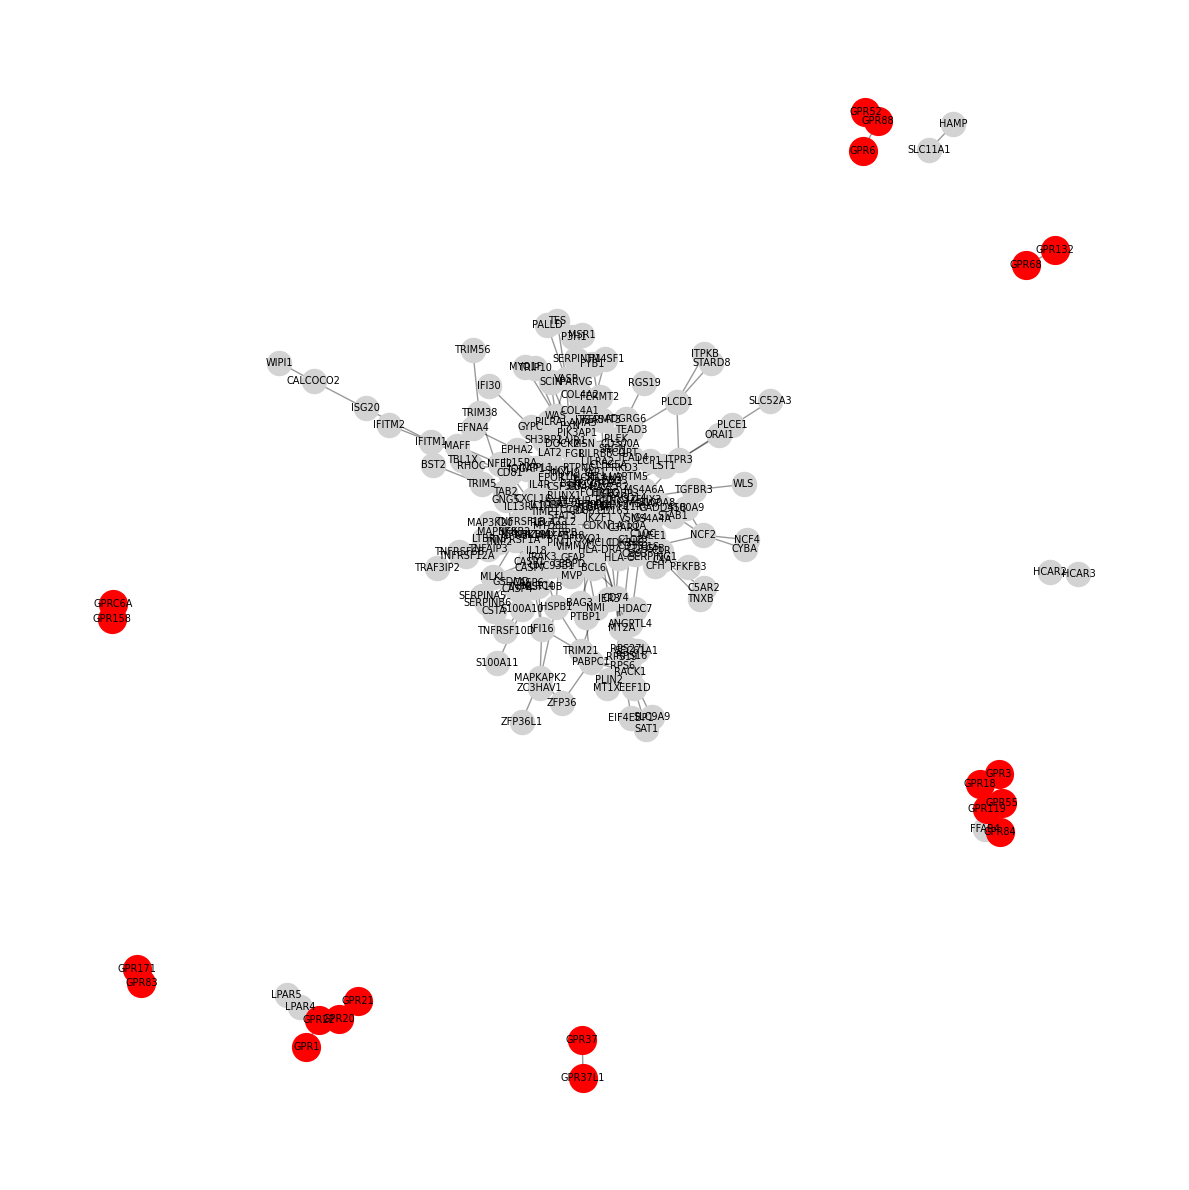

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/raw/GPR.csv")

# Create graph
G = nx.Graph()

# Add edges
for _, row in df.iterrows():
    G.add_edge(
        row["#node1"],
        row["node2"],
        weight=row["combined_score"]
    )

# Find GPR nodes
gpr_nodes = [node for node in G.nodes if str(node).startswith("GPR")]

# Count unique edges connected to GPR nodes
gpr_edges = [
    (u, v)
    for u, v in G.edges()
    if u in gpr_nodes or v in gpr_nodes
]

print(f"Total unique edges connected to GPR nodes: {len(gpr_edges)}")

# Individual GPR node degree
print("\nEdges per GPR node:")
for node in gpr_nodes:
    print(f"{node}: {G.degree(node)}")
# Layout
pos = nx.spring_layout(
    G,
    seed=42,

)

# Plot
plt.figure(figsize=(12, 12))

# Edges
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.4,
    width=1
)

# Normal nodes
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=other_nodes,
    node_size=300,
    node_color="lightgray"
)

# GPR nodes
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=gpr_nodes,
    node_size=400,
    node_color="red"
)

# Labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=7
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt


gpr= pd.read_excel("../test/GPR (3).xlsx")
gse = pd.read_excel("../test/GSE44770_AD_vs_Control_DEGs1.xlsx")

genes1 = set(gpr["#node1"])
genes2 = set(gpr["node2"])

genes = genes1 | genes2


gpr_genes = {gene for gene in genes if str(gene).startswith("GPR")}

other_genes = genes - gpr_genes

gpr_genes = pd.DataFrame(sorted(gpr_genes), columns=["gene"])
other_genes = pd.DataFrame(sorted(other_genes), columns=["gene"])

expression = gse[["Gene symbol","logFC"]].dropna().set_index("Gene symbol")

expression.index.names = ["gene"]

gpr_expression = gpr_genes.merge(expression,on='gene',how='left')

other_expression = other_genes.merge(expression,on='gene',how = 'left')


In [3]:
all = pd.concat([gpr_expression,other_expression])

all.to_excel("../test/all_expression.xlsx")

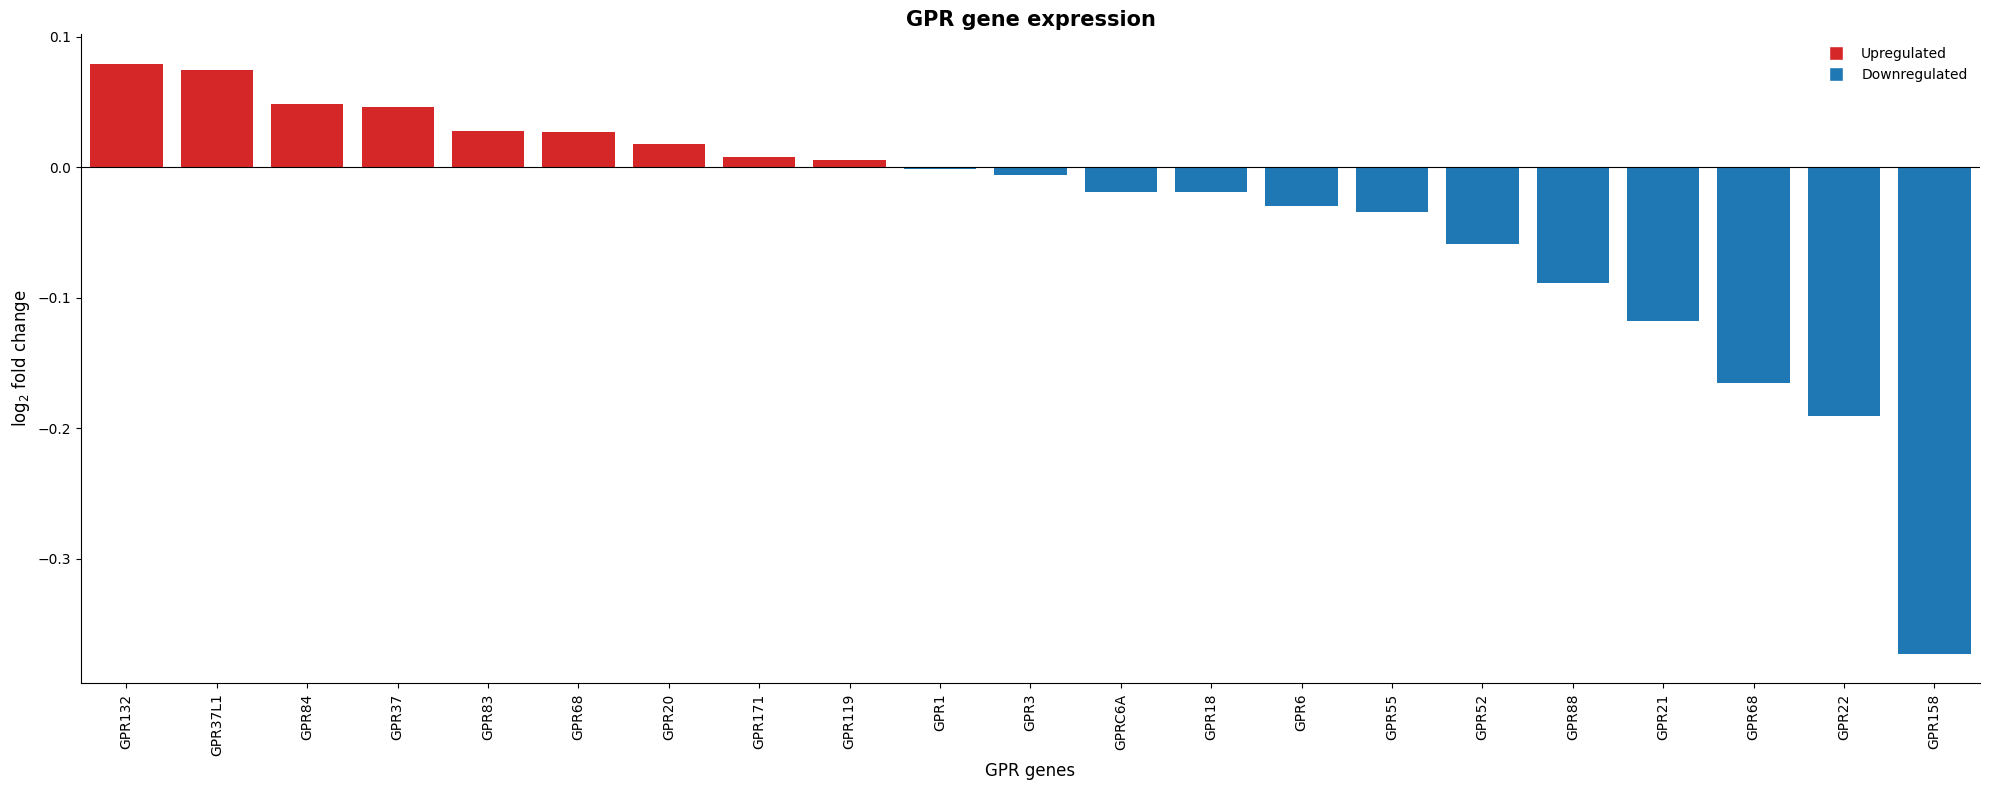

Saved: ../data/raw\gpr_gene_expression.tiff


In [ ]:




# ============================================================
# PREPARE DATA
# ============================================================

df = gpr_expression.copy()

df["gene"] = (
    df["gene"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df.dropna(subset=["logFC"])

# Use sign to define color
df["color"] = df["logFC"].apply(
    lambda value: "#d62728" if value > 0 else "#1f77b4"
)

# Sort from largest positive to largest negative effect
df = df.sort_values(
    by="logFC",
    ascending=False,
    kind="mergesort"
).reset_index(drop=True)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(20, 8))

x = range(len(df))

ax.bar(
    x,
    df["logFC"],
    color=df["color"],
    width=0.8
)

ax.axhline(0, color="black", linewidth=0.8)

label_fontsize = (
    10 if len(df) <= 25 else
    8 if len(df) <= 45 else
    6 if len(df) <= 70 else
    5
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    df["gene"],
    rotation=90,
    fontsize=label_fontsize,
    ha="center",
    va="top"
)

ax.tick_params(axis="x", pad=4)
ax.margins(x=0.005)

ax.set_ylabel("log$_2$ fold change", fontsize=12)
ax.set_xlabel("GPR genes", fontsize=12)
ax.set_title(
    "GPR gene expression",
    fontsize=15,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        color="w",
        markerfacecolor="#d62728",
        markersize=10,
        label="Upregulated"
    ),
    plt.Line2D(
        [0], [0],
        marker="s",
        color="w",
        markerfacecolor="#1f77b4",
        markersize=10,
        label="Downregulated"
    )
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper right"
)

fig.subplots_adjust(bottom=0.35, top=0.90)
plt.tight_layout()

outfile = os.path.join(
    "../data/raw",
    "gpr_gene_expression.tiff"
)

plt.savefig(outfile, format="tiff", bbox_inches="tight")
plt.show()

print(f"Saved: {outfile}")

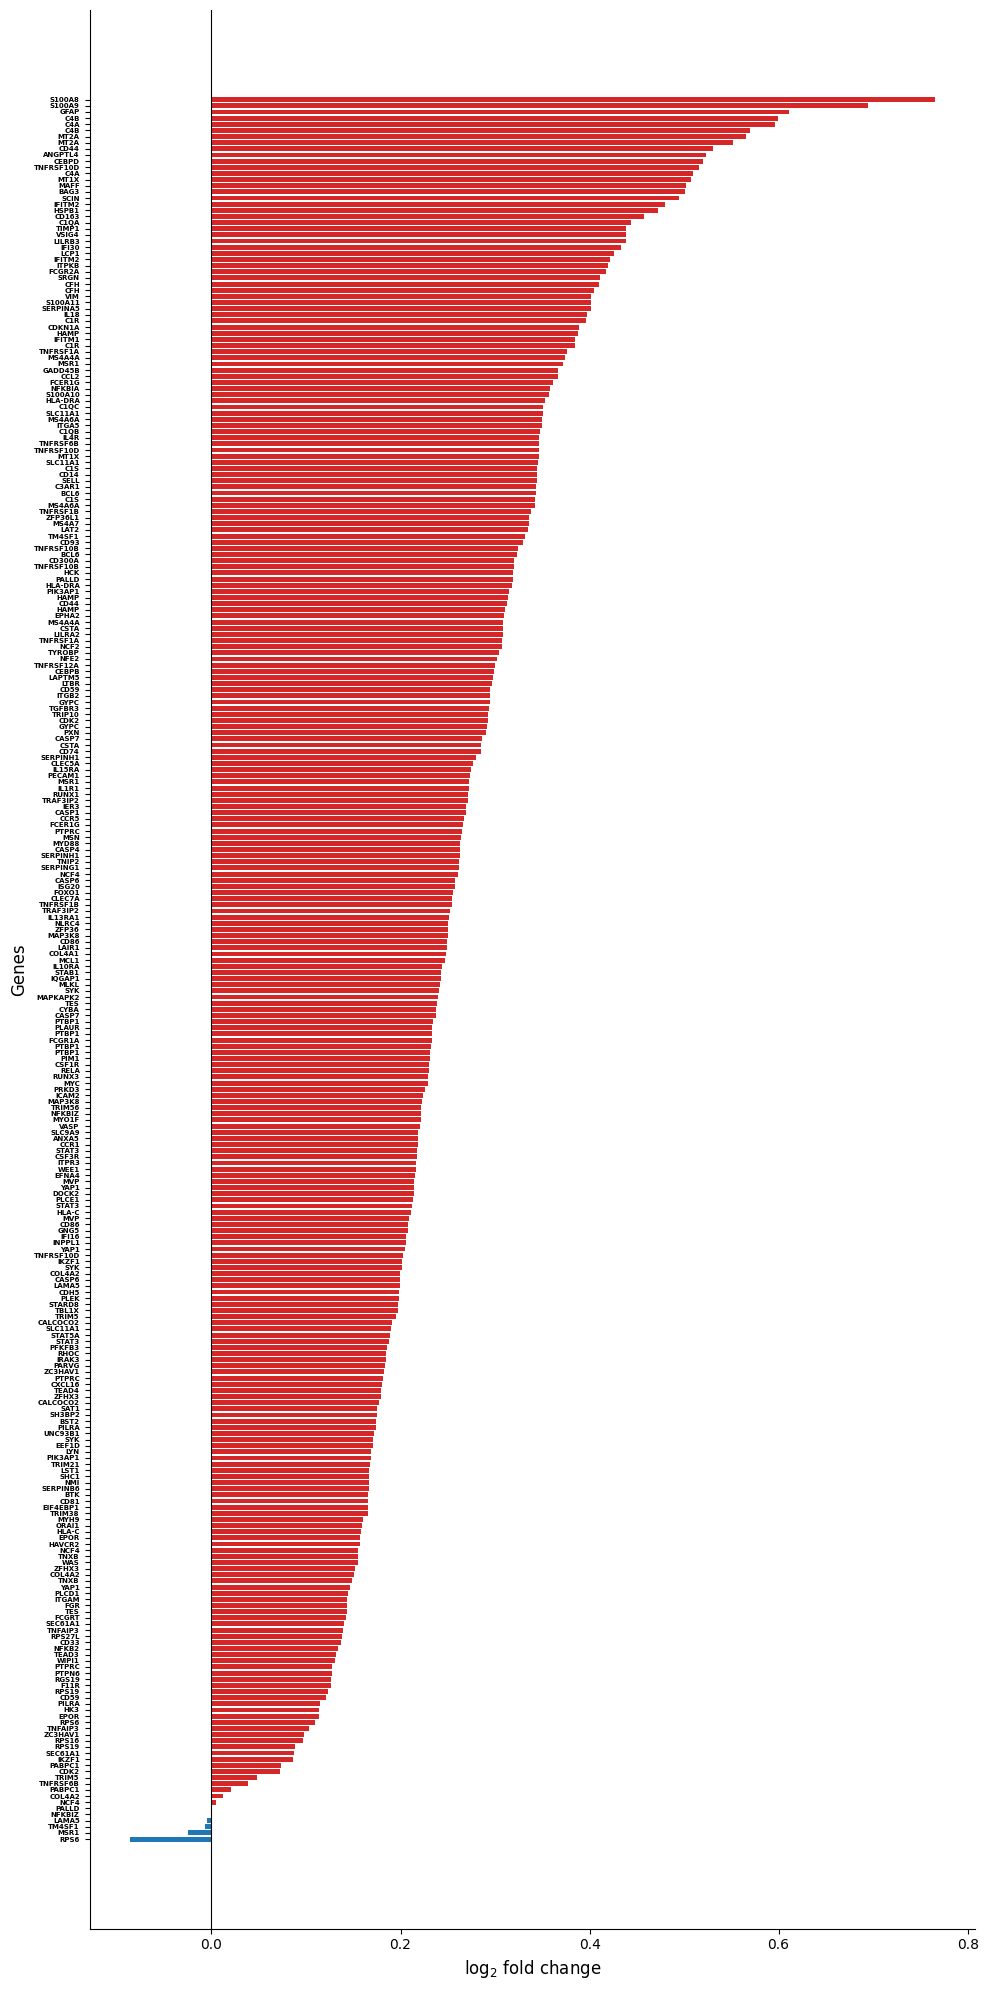

Saved: ../test\other_gene_expression.tiff


In [19]:
# ============================================================
# PREPARE DATA
# ============================================================

df = other_expression.copy()

df["gene"] = (
    df["gene"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df.dropna(subset=["logFC"])

# Use sign to define color
df["color"] = df["logFC"].apply(
    lambda value: "#d62728" if value > 0 else "#1f77b4"
)

# Sort from largest positive to largest negative effect
df = df.sort_values(
    by="logFC",
    ascending=False,
    kind="mergesort"
).reset_index(drop=True)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 20))

y = range(len(df))

ax.barh(
    y,
    df["logFC"],
    color=df["color"],
    height=0.8
)

ax.axvline(0, color="black", linewidth=0.8)

# Bold gene names
label_fontsize = (
    10 if len(df) <= 25 else
    8 if len(df) <= 45 else
    6 if len(df) <= 70 else
    5
)

ax.set_yticks(list(y))
ax.set_yticklabels(
    df["gene"],
    fontsize=label_fontsize,
    fontweight="bold"
)

ax.tick_params(axis="y", pad=4)

ax.set_xlabel("log$_2$ fold change", fontsize=12)
ax.set_ylabel("Genes", fontsize=12)

# No title

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Put largest positive values at the top
ax.invert_yaxis()

fig.subplots_adjust(left=0.25, right=0.97, top=0.98, bottom=0.08)

plt.tight_layout()

outfile = os.path.join(
    "../test",
    "other_gene_expression.tiff"
)

plt.savefig(
    outfile,
    format="tiff",
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {outfile}")

In [4]:



# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(input_path, index_col=0)

df.index = (
    df.index
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df[["log2FC_rna", "category_rna"]].copy()
df = df.dropna(subset=["log2FC_rna"]).reset_index()

df = df.rename(columns={"index": "gene"})

# Use sign to define color, regardless of significance class.
df["color"] = df["log2FC_rna"].apply(
    lambda value: "#d62728" if value > 0 else "#1f77b4"
)

# Sort from largest positive to largest negative effect.
df = df.sort_values(
    by="log2FC_rna",
    ascending=False,
    kind="mergesort"
).reset_index(drop=True)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(20, 8))

x = range(len(df))

ax.bar(
    x,
    df["log2FC_rna"],
    color=df["color"],
    width=0.8
)

ax.axhline(0, color="black", linewidth=0.8)

label_fontsize = (
    10 if len(df) <= 25 else
    8 if len(df) <= 45 else
    6 if len(df) <= 70 else
    5
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    df["gene"],
    rotation=90,
    fontsize=label_fontsize,
    ha="center",
    va="top"
)
ax.tick_params(axis="x", pad=4)
ax.margins(x=0.005)

ax.set_ylabel("log$_2$ fold change", fontsize=12)
ax.set_xlabel("Classical apoptosis genes", fontsize=12)
ax.set_title(
    "Dysregulated apoptosis gene expression",
    fontsize=15,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend to make the red/blue split explicit.
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#d62728", markersize=10, label="Upregulated"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#1f77b4", markersize=10, label="Downregulated")
]
ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper right"
)

fig.subplots_adjust(bottom=0.35, top=0.90)
plt.tight_layout()

outfile = os.path.join(
    outdir,
    "classical_apoptosis_log2fc.tiff"
)
plt.savefig(outfile, format="tiff", bbox_inches="tight")
plt.show()

print(f"Saved: {outfile}")


NameError: name 'input_path' is not defined